<a href="https://colab.research.google.com/github/Krishrdx/ML_to_GenAI_Journey/blob/main/Month_02_Algos_%26_Building_Data/Week_01_Handling_data/Day_01_Handling_missing_data_for_Numeric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [39]:
df = sns.load_dataset('titanic')

In [40]:
df.sample(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
19,1,3,female,NaN,0,0,7.2250,C,Third,woman,False,NaN,Cherbourg,yes,True
833,0,3,male,23.0,0,0,7.8542,S,Third,man,True,NaN,Southampton,no,True
331,0,1,male,45.5,0,0,28.5000,S,First,man,True,C,Southampton,no,True


### MEAN MEDIAN IMPUTATION

In [48]:
df['fare'].value_counts()

,count
fare,
13.0000,42
7.8958,38
7.7500,34
26.0000,31
10.5000,24
...,...
13.8583,1
50.4958,1
5.0000,1


In [45]:
df.loc[df['fare'] == 8.0500, 'fare'] = np.nan


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         848 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [51]:
df.isnull().mean()*100

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,19.865320
sibsp,0.000000
parch,0.000000
fare,4.826038
embarked,0.224467
class,0.000000
who,0.000000


In [52]:
df_new = df[['age','alone','fare','survived']]

In [53]:
df_new.sample(4)

,age,alone,fare,survived
630,80.0,True,30.0000,1
384,NaN,True,7.8958,0
776,NaN,True,7.7500,0
37,21.0,True,NaN,0


In [54]:
x = df_new.drop(columns='survived')
y = df_new.iloc[:,:-1]

In [55]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state = 2)

In [56]:
x_train.shape

(712, 3)

In [57]:
x_test.shape

(179, 3)

In [58]:
x_train.isnull().mean()

,0
age,0.207865
alone,0.000000
fare,0.046348


In [59]:
mean_age = x_train['age'].mean()
median_age = x_train['age'].median()

mean_fare = x_train['fare'].mean()
median_fare = x_train['fare'].median()


In [61]:
print(mean_age,
median_age,
mean_fare,
median_fare)

29.78590425531915 28.75 33.46709558173785 15.5


In [62]:
x_train['age_median'] = x_train['age'].fillna(median_age)
x_train['age_mean'] = x_train['age'].fillna(mean_age)

x_train['fare_mean'] = x_train['fare'].fillna(mean_fare)
x_train['fare_median'] = x_train['fare'].fillna(median_fare)

In [73]:
x_train.sample(3)

,age,alone,fare,age_median,age_mean,fare_mean,fare_median
527,NaN,True,221.7792,28.75,29.785904,221.7792,221.7792
742,21.0,False,262.3750,21.00,21.000000,262.3750,262.3750
92,46.0,False,61.1750,46.00,46.000000,61.1750,61.1750


In [74]:
print('Original age variable variance: ', x_train['age'].var())
print('age variable variance after mean imputation: ', x_train['age_mean'].var())
print('age variable variance after median imputation: ', x_train['age_median'].var())


print('Original Fare variable variance: ', x_train['fare'].var())
print('Fare variable variance after mean imputation: ', x_train['fare_mean'].var())
print('Fare variable variance after median imputation: ', x_train['fare_median'].var())


Original age variable variance:  204.3495133904614
age variable variance after mean imputation:  161.81262452718673
age variable variance after median imputation:  161.9895663346054
Original Fare variable variance:  2453.5289771583284
Fare variable variance after mean imputation:  2339.652104800769
Fare variable variance after median imputation:  2353.9407112999174


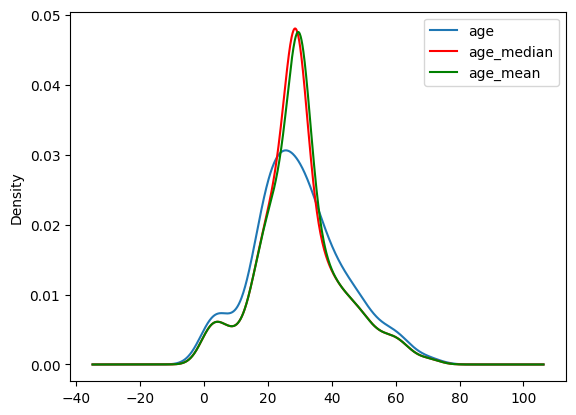

In [76]:
fig = plt.figure()
ax = fig.add_subplot(111)

#Orginal distribution
x_train['age'].plot(kind='kde', ax=ax)

#variable imputed with the median
x_train['age_median'].plot(kind='kde', ax=ax, color='red')

#variable imputed with the mean
x_train['age_mean'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()


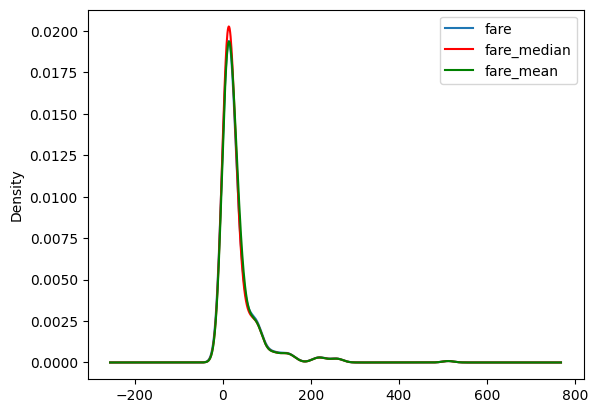

In [77]:
fig = plt.figure()
ax = fig.add_subplot(111)

#Orginal distribution
x_train['fare'].plot(kind='kde', ax=ax)

#variable imputed with the median
x_train['fare_median'].plot(kind='kde', ax=ax, color='red')

#variable imputed with the mean
x_train['fare_mean'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()


In [78]:
x_train.cov()

,age,alone,fare,age_median,age_mean,fare_mean,fare_median
age,204.349513,1.389514,76.231312,204.349513,204.349513,73.205228,72.008613
alone,1.389514,0.239825,-6.661861,1.069934,1.100276,-6.352660,-6.684118
fare,76.231312,-6.661861,2453.528977,63.063594,60.788412,2453.528977,2453.528977
age_median,204.349513,1.069934,63.063594,161.989566,161.812625,60.136592,59.323625
age_mean,204.349513,1.100276,60.788412,161.812625,161.812625,57.967009,57.019478
fare_mean,73.205228,-6.352660,2453.528977,60.136592,57.967009,2339.652105,2339.652105
fare_median,72.008613,-6.684118,2453.528977,59.323625,57.019478,2339.652105,2353.940711


In [79]:
x_train.corr()

,age,alone,fare,age_median,age_mean,fare_mean,fare_median
age,1.000000,0.195926,0.099956,1.000000,1.000000,0.098594,0.096711
alone,0.195926,1.000000,-0.272589,0.171659,0.176624,-0.268184,-0.281319
fare,0.099956,-0.272589,1.000000,0.098791,0.095270,1.000000,1.000000
age_median,1.000000,0.171659,0.098791,1.000000,0.999454,0.097683,0.096070
age_mean,1.000000,0.176624,0.095270,0.999454,1.000000,0.094210,0.092389
fare_mean,0.098594,-0.268184,1.000000,0.097683,0.094210,1.000000,0.996960
fare_median,0.096711,-0.281319,1.000000,0.096070,0.092389,0.996960,1.000000


<Axes: >

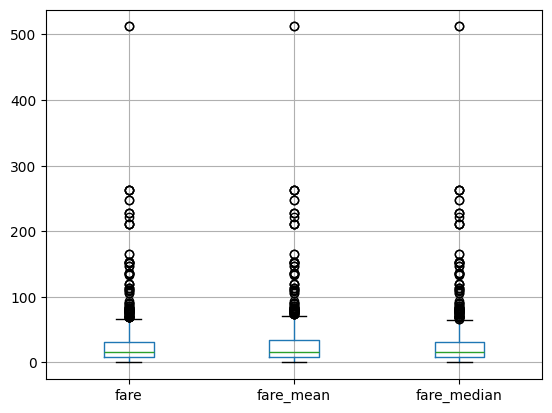

In [80]:
x_train[['fare', 'fare_mean','fare_median']].boxplot()

<Axes: >

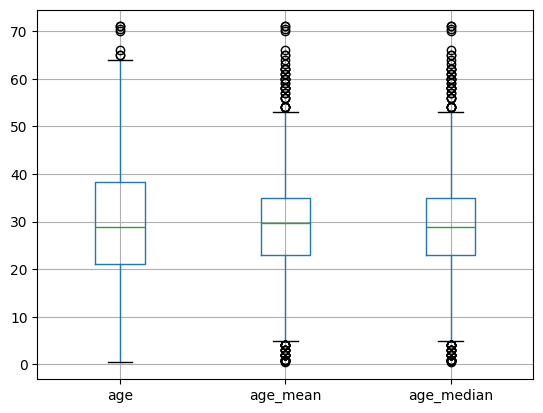

In [81]:
x_train[['age', 'age_mean','age_median']].boxplot()

The Outliers are hilarious, you can set that for age column

### USING SKLEARN

In [82]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)


In [83]:
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [84]:
trf = ColumnTransformer([
    ('mean_imputer', imputer2, ['age']),
    ('median_imputer', imputer1, ['fare'])],
    remainder = 'passthrough')

In [85]:
trf.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('mean_imputer',
                                 SimpleImputer(strategy='median'), ['age']),
                                ('median_imputer', SimpleImputer(), ['fare'])])

In [91]:
trf.named_transformers_[ 'median_imputer'].statistics_

array([33.46709558])

### End of DISTSRIBUTION Imputation

In [92]:
p_train, p_test, q_train, q_test = train_test_split(x, y, test_size=0.2, random_state = 2)

In [93]:
p_train['age_99'] = p_train['age'].fillna(99)
p_train['age_minus-1'] = p_train['age'].fillna(-1)

p_train['fare_99'] = p_train['fare'].fillna(99)
p_train['fare_minus-1'] = p_train['fare'].fillna(-1)

In [95]:
print('Original age variable variance: ', p_train['age'].var())
print('age variable variance after 99+ imputation: ', p_train['age_99'].var())
print('age variable variance after -1 imputation: ', p_train['age_minus-1'].var())


print('Original Fare variable variance: ', p_train['fare'].var())
print('Fare variable variance after 99+ imputation: ', p_train['fare_99'].var())
print('Fare variable variance after -1 imputation: ', p_train['fare_minus-1'].var())


Original age variable variance:  204.3495133904614
age variable variance after 99+ imputation:  951.7275570187172
age variable variance after -1 imputation:  318.0896202624484
Original Fare variable variance:  2453.5289771583284
Fare variable variance after 99+ imputation:  2529.7393393263915
Fare variable variance after -1 imputation:  2392.2348791974377


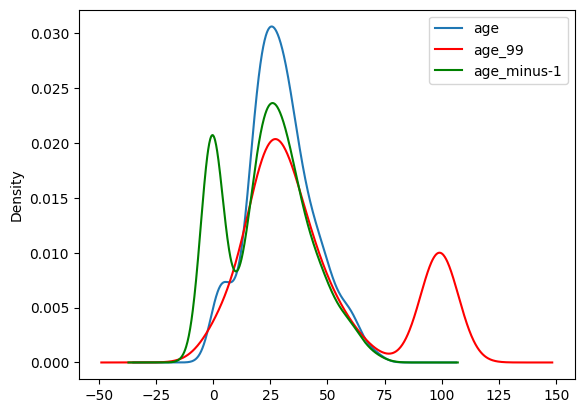

In [97]:
fig = plt.figure()
ax = fig.add_subplot(111)

#Orginal distribution
p_train['age'].plot(kind='kde', ax=ax)

#variable imputed with the median
p_train['age_99'].plot(kind='kde', ax=ax, color='red')

#variable imputed with the mean
p_train['age_minus-1'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()


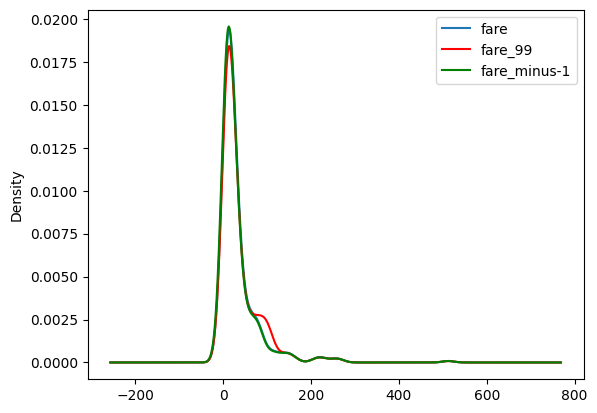

In [99]:
fig = plt.figure()
ax = fig.add_subplot(111)

#Orginal distribution
p_train['fare'].plot(kind='kde', ax=ax)

#variable imputed with the median
p_train['fare_99'].plot(kind='kde', ax=ax, color='red')

#variable imputed with the mean
p_train['fare_minus-1'].plot(kind='kde', ax=ax, color='green')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

plt.show()


In [100]:
p_train.cov()

,age,alone,fare,age_99,age_minus-1,fare_99,fare_minus-1
age,204.349513,1.389514,76.231312,204.349513,204.349513,77.569744,70.909706
alone,1.389514,0.239825,-6.661861,3.127621,0.198529,-5.143705,-6.988511
fare,76.231312,-6.661861,2453.528977,-91.228242,128.404265,2453.528977,2453.528977
age_99,204.349513,3.127621,-91.228242,951.727557,-189.535540,-50.744685,-106.059393
age_minus-1,204.349513,0.198529,128.404265,-189.535540,318.089620,111.314361,128.298520
fare_99,77.569744,-5.143705,2453.528977,-50.744685,111.314361,2529.739339,2239.675537
fare_minus-1,70.909706,-6.988511,2453.528977,-106.059393,128.298520,2239.675537,2392.234879


In [101]:
p_train.corr()

,age,alone,fare,age_99,age_minus-1,fare_99,fare_minus-1
age,1.000000,0.195926,0.099956,1.000000,1.000000,0.101839,0.094639
alone,0.195926,1.000000,-0.272589,0.207019,0.022730,-0.208829,-0.291767
fare,0.099956,-0.272589,1.000000,-0.060202,0.145531,1.000000,1.000000
age_99,1.000000,0.207019,-0.060202,1.000000,-0.344476,-0.032704,-0.070290
age_minus-1,1.000000,0.022730,0.145531,-0.344476,1.000000,0.124091,0.147077
fare_99,0.101839,-0.208829,1.000000,-0.032704,0.124091,1.000000,0.910427
fare_minus-1,0.094639,-0.291767,1.000000,-0.070290,0.147077,0.910427,1.000000


###Same for put the Values of 99 and -1 and any other that suits the data using SKLEARN